In [1]:
%matplotlib ipympl

import datetime as dt
import time
from urllib.error import URLError

import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import utils
from tqdm.notebook import tqdm

plt.style.use("ggplot")

In [2]:
eng = nivapy.da.connect_postgis()

Connection successful.


# Benchmark random sampling to improve query performance of the GTS API

`nivapy` includes functions to query data from the GTS API. One option is to query data for whole polygons (e.g. catchments).

The GTS API provides gridded data with 1 km resolution. NVE do not use flow routing in their hydrological model, so an easy way to estimate discharge for any point is to get the simulated runoff for each grid cell within the catchment of interest, convert runoff to volume, and then sum the values over all cells.

$$Q = \sum_{i=1}^{N} \frac{1000 R_i}{24 \times 60 \times 60}$$

Where $Q$ is flow in $m^3/s$; $R_i$ is the daily runoff from cell $i$ in $mm$; and $N$ is the number of grid cells in the catchment. However, this requires $N$ API calls, which is slow for large catchments. An equivalent approach is to first calculate the mean of all runoff values

$$\overline{R} = \frac{1}{N} \sum_{i=1}^{N} R_i$$

and then estimate $Q$ as

$$Q = \frac{1000 A \overline{R}}{24 \times 60 \times 60}$$

(This works because, at 1 km grid resolution, the number of 1 km2 cells in the catchment, $N$, is the same as the catchment area, $A$).

Instead of making $N$ API requests, we can obtain an *estimate* for the mean runoff ($\hat{R}$) by sampling just $n$ grid cells at random from within the catchment and estimating the daily flow as

$$\hat{R} = \frac{1}{n} \sum_{i=1}^{n} R_i$$

$$\hat{Q} = \frac{1000 A \hat{R}}{24 \times 60 \times 60}$$

If $n \ll N$, this will be much faster.

For simple random sampling of grid cells without replacement, the **standard error** (SE) of the mean is

$$SE(\hat{\mu}) = \sigma \sqrt{\frac{1}{n} \left( 1 - \frac{n}{N} \right)}$$

or, if $n \ll N$

$$SE(\hat{\mu}) \approx \frac{\sigma}{\sqrt{n}}$$

Where $\sigma$ is the standard deviation of runoff within the catchment. The **relative error** (RSE) is the SE divided by the mean

$$\frac{SE(\hat{\mu})}{\mu} \approx \frac{\sigma}{\mu \sqrt{n}}$$

In this context, $\frac{\sigma}{\mu}$ is the **spatial coefficient of variation** (CV), which represents the variability of the spatial field.

$$RSE = \frac{CV}{\sqrt{n}}$$

If we want an estimate of the mean runoff that is accurate to $p$ percent, we need

$$n = \left( \frac{100 CV}{p} \right) ^2$$

The CV for each catchment can be estimated by sampling, or by getting all the data for a few catchments and dividing the standard deviation by the mean. Copilot suggests typical values for Norwegian catchments of 0.3 to 0.6. Assuming 0.5 gives the following rough sample sizes

| **p** | **n** |
|:-----:|:-----:|
|    10 |    25 |
|     5 |   100 |
|     3 |   278 |
|     2 |   625 |
|     1 |  2500 |

In terms of simulating runoff, errors of 3 - 5% are acceptable, which imples 100 to 300 samples should be sufficient, even for large catchments.

The code below uses the API to samples values for large catchments and estimate daily flows. Results are compared to measured data from NVE monitoring stations. **Note that the model underpinning the GTS API does not include water transfers due to hydropower etc.** In many cases, this means the model itself performs poorly i.e. the flow simulations do not match the observed series very well, even if we query all cells in the catchment and estimate $\overline{R}$ exactly. However, for many catchments it is still the best data source for daily flows. 

The goal here is to compare different sampling strategies to see how many samples are necessary to obtain a reasonable estimate of mean catchment runoff.

## 1. Read test data

In [3]:
# Observed data
csv_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_values.csv"
)
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
csv_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_stations.csv"
)
stn_df = pd.read_csv(csv_path)

# Catchment boundaries
gpkg_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
)
cat_gdf = gpd.read_file(gpkg_path, layer="water_temp_catchments")

display(df.head())
display(stn_df.head())
display(cat_gdf.head())

,station_id,station_name,date,water_temp_c,discharge_m3ps
0,1.200.0,Lierelv,2010-09-15,16.71710,0.577649
1,1.200.0,Lierelv,2010-09-16,11.95146,0.837333
2,1.200.0,Lierelv,2010-09-17,11.43837,0.747467
3,1.200.0,Lierelv,2010-09-18,10.87446,0.682479
4,1.200.0,Lierelv,2010-09-19,10.17794,0.636813


,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,cat_elev_max_m,regulation_type,regulated_area_km2,transfer_area_in_km2,transfer_area_out_km2,reservoir_area_in_km2,reservoir_area_out_km2,reservoir_vol_in_??,reservoir_vol_out_??,unregulated_area_km2
0,1.200.0,Lierelv,59.92038,11.53180,306146,6647624,134,Haldenvassdraget,3226.0,Aurskog-Høland,...,402.0,regulert m/magasinregulering,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,1.41.0,Lognselva,59.80011,11.44331,300484,6634505,148,Haldenvassdraget,3226.0,Aurskog-Høland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,102.1.0,Hildreelv,62.60018,6.34442,56566,6970861,37,Hildreelva,1580.0,Haram,...,786.0,Uregulert,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,103.12.0,Verma kraftstasjon,62.34783,8.05015,140646,6932269,167,Rauma,1539.0,Rauma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,103.3.0,Rauma v/Stuguflåten,62.27660,8.15311,145115,6923797,521,Rauma,3432.0,Lesja,...,2012.0,Uregulert,9.0,0.0,9.0,0.0,0.0,0.0,0.0,368.09


,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,regulated_area_km2,transfer_area_in_km2,transfer_area_out_km2,reservoir_area_in_km2,reservoir_area_out_km2,reservoir_vol_in_??,reservoir_vol_out_??,unregulated_area_km2,cat_area_km2,geometry
0,1.200.0,Lierelv,59.92038,11.53180,306146,6647624,134,Haldenvassdraget,3226.0,Aurskog-Høland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,133.893055,"MULTIPOLYGON (((306720 6664200, 306720 6664160..."
1,1.41.0,Lognselva,59.80011,11.44331,300484,6634505,148,Haldenvassdraget,3226.0,Aurskog-Høland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.640887,"MULTIPOLYGON (((300600 6642960, 300600 6642880..."
2,102.1.0,Hildreelv,62.60018,6.34442,56566,6970861,37,Hildreelva,1580.0,Haram,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,14.208538,"MULTIPOLYGON (((56400 6970920, 56400 6970880, ..."
3,103.12.0,Verma kraftstasjon,62.34783,8.05015,140646,6932269,167,Rauma,1539.0,Rauma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,873.537221,"MULTIPOLYGON (((144200 6933440, 144200 6933400..."
4,103.3.0,Rauma v/Stuguflåten,62.27660,8.15311,145115,6923797,521,Rauma,3432.0,Lesja,...,9.0,0.0,9.0,0.0,0.0,0.0,0.0,368.09,376.160270,"MULTIPOLYGON (((148000 6932760, 148000 6932720..."


## 2. Pick a test catchment

Find a suitable catchment using the parameters below. Make sure it has some observed discharge data to compare against.

In [4]:
cat_gdf2 = cat_gdf.query("cat_area_km2 > 5000").iloc[[6]]
stn_id = cat_gdf2.iloc[0]["station_id"]
val_df = df.query("station_id == @stn_id").copy().dropna(subset="discharge_m3ps")
display(cat_gdf2)
display(val_df.head())

,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,regulated_area_km2,transfer_area_in_km2,transfer_area_out_km2,reservoir_area_in_km2,reservoir_area_out_km2,reservoir_vol_in_??,reservoir_vol_out_??,unregulated_area_km2,cat_area_km2,geometry
158,16.497.0,Farelva ndf. Skotfoss,59.20338,9.55242,189095,6575410,15,Skiensvassdraget,4003.0,Skien,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10370.206522,"MULTIPOLYGON (((174840 6567480, 174840 6567520..."


,station_id,station_name,date,water_temp_c,discharge_m3ps
982605,16.497.0,Farelva ndf. Skotfoss,2012-11-21,6.504376,418.1063
982606,16.497.0,Farelva ndf. Skotfoss,2012-11-22,6.178750,493.3838
982607,16.497.0,Farelva ndf. Skotfoss,2012-11-23,5.861041,533.7547
982608,16.497.0,Farelva ndf. Skotfoss,2012-11-24,5.953749,548.1571
982609,16.497.0,Farelva ndf. Skotfoss,2012-11-25,6.127292,523.4716


## 3. Query API

In [5]:
# Query API
samp_sizes = [100, 200, 500, 1000, 5000]
max_retries = 5

stn_id = cat_gdf2.iloc[0]["station_id"]
cat_area = cat_gdf2.iloc[0]["cat_area_km2"]
val_df = df.query("station_id == @stn_id").copy()
st_dt = val_df["date"].min().strftime("%Y-%m-%d")
end_dt = val_df["date"].max().strftime("%Y-%m-%d")

print(stn_id)
print(st_dt, end_dt)

df_list = []
for n_samp in samp_sizes:
    retries = 0
    while retries < max_retries:
        try:
            stat_df = utils.get_nve_gts_api_aggregated_time_series(
                cat_gdf2,
                ["gwb_q"],
                st_dt,
                end_dt,
                id_col="station_id",
                n_samp=n_samp,
                random_state=42,
            )[["datetime", "value_mean"]].set_index("datetime")
            stat_df[f"discharge_m3ps_n{n_samp}"] = (
                1e6 * cat_area * stat_df["value_mean"] / (1000 * 24 * 60 * 60)
            )
            df_list.append(stat_df[f"discharge_m3ps_n{n_samp}"])
            break
        except URLError as e:
            retries += 1
            time.sleep(5)

stat_df = pd.concat(df_list, axis="columns").resample("D").mean()
stat_df["date"] = pd.to_datetime(stat_df.index.date)
stat_df = stat_df.reset_index(drop=True)
val_df = pd.merge(
    val_df[["date", "discharge_m3ps"]], stat_df, how="outer", on="date"
).set_index("date")
val_df.head()

16.497.0
2012-11-21 2025-12-31


/home/jovyan/projects/mjosa_water_temp/code/utils.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pt_df = pt_df.groupby(id_col, group_keys=False).apply(


Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/100 [00:00<?, ?it/s]

/home/jovyan/projects/mjosa_water_temp/code/utils.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pt_df = pt_df.groupby(id_col, group_keys=False).apply(


...

Looping over grid cells:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jovyan/projects/mjosa_water_temp/code/utils.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pt_df = pt_df.groupby(id_col, group_keys=False).apply(


Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/5000 [00:00<?, ?it/s]

,discharge_m3ps,discharge_m3ps_n100,discharge_m3ps_n200,discharge_m3ps_n500,discharge_m3ps_n1000,discharge_m3ps_n5000
date,,,,,,
2012-11-21,418.1063,237.050438,236.450311,241.275337,235.430094,241.635414
2012-11-22,493.3838,355.755696,358.936373,359.260442,351.530797,361.605741
2012-11-23,533.7547,436.772934,439.953611,437.949185,429.787448,442.543762
2012-11-24,548.1571,435.572679,437.072998,435.476659,425.214475,438.489300
2012-11-25,523.4716,388.882745,390.563102,390.010985,379.772806,391.300059


<Axes: xlabel='date'>

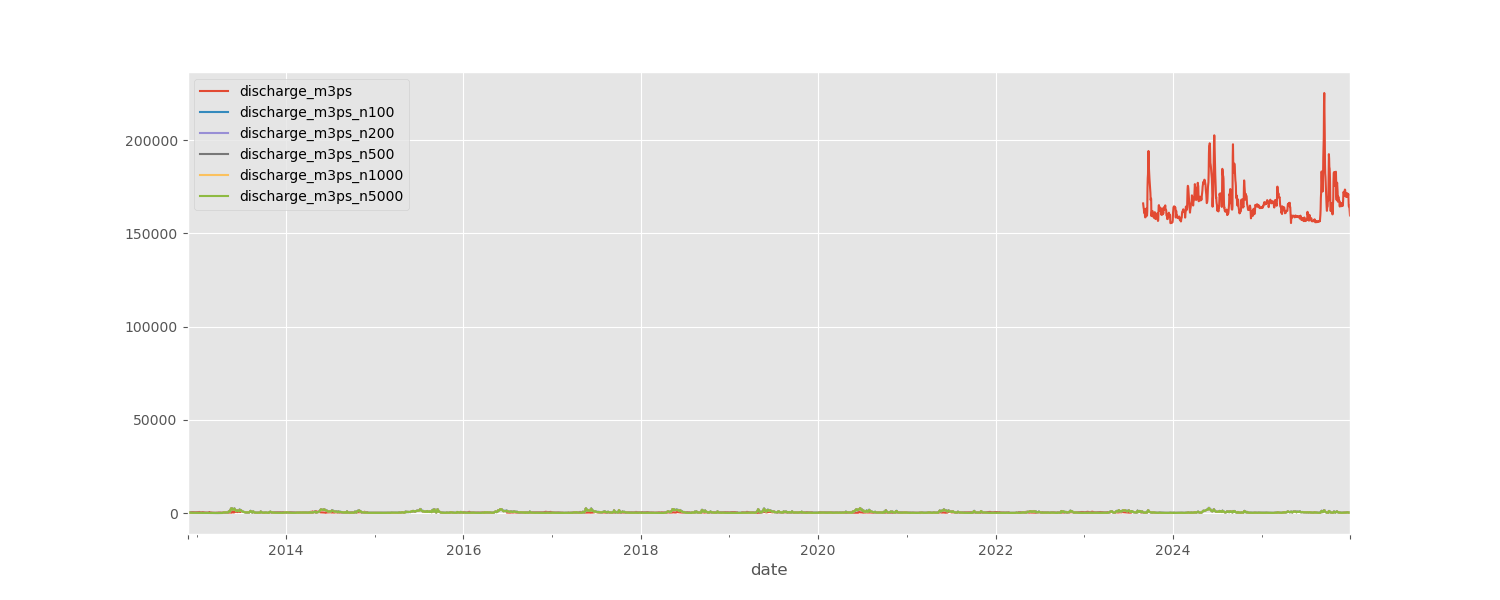

In [6]:
# Plot
val_df.plot(figsize=(15, 6))

## 4. Summary

In general, there is very little difference between the curves estimated using 100 to 200 samples and those from 1000 to 5000 samples. In most cases, errors caused by the model not including water transfers are much larger than those due to stochastic sampling.

Based on this, **the theoretical estimate of 100 to 300 samples per catchment seems like a good way to efficiently query runoff data from the GTS API**.

In [7]:
# pars = ["tm", "rr", "gwb_q", "qtt"]
# max_retries = 5

# # Filter stations and data to just catchments with land cover properties
# stn_ids = cat_gdf["station_id"].unique().tolist()
# stn_df = stn_df.query("station_id in @stn_ids")
# df = df.query("station_id in @stn_ids")
# assert (
#     len(stn_ids)
#     == len(stn_df["station_id"].unique().tolist())
#     == len(df["station_id"].unique().tolist())
# )

# # Loop over time series
# for stn_id, val_df in df.groupby("station_id"):
#     retries = 0
#     while retries < max_retries:
#         try:
#             stn_gdf = cat_gdf.query("station_id == @stn_id").copy()
#             val_df = val_df.dropna(subset="water_temp_c")
#             st_dt = val_df["date"].min().strftime("%Y-%m-%d")
#             end_dt = val_df["date"].max().strftime("%Y-%m-%d")
#             stat_df = get_nve_gts_api_aggregated_time_series(
#                 stn_gdf,
#                 pars,
#                 st_dt,
#                 end_dt,
#                 id_col="station_id",
#                 n_samp=1000,
#                 random_state=42,
#             )
#             print(stat_df)
#             break
#         except URLError as e:
#             retries += 1
#             time.sleep(5)